# Diagnostic 
Phân tích return rate theo kích cỡ & danh mục, nguyên nhân nào chiếm đa số

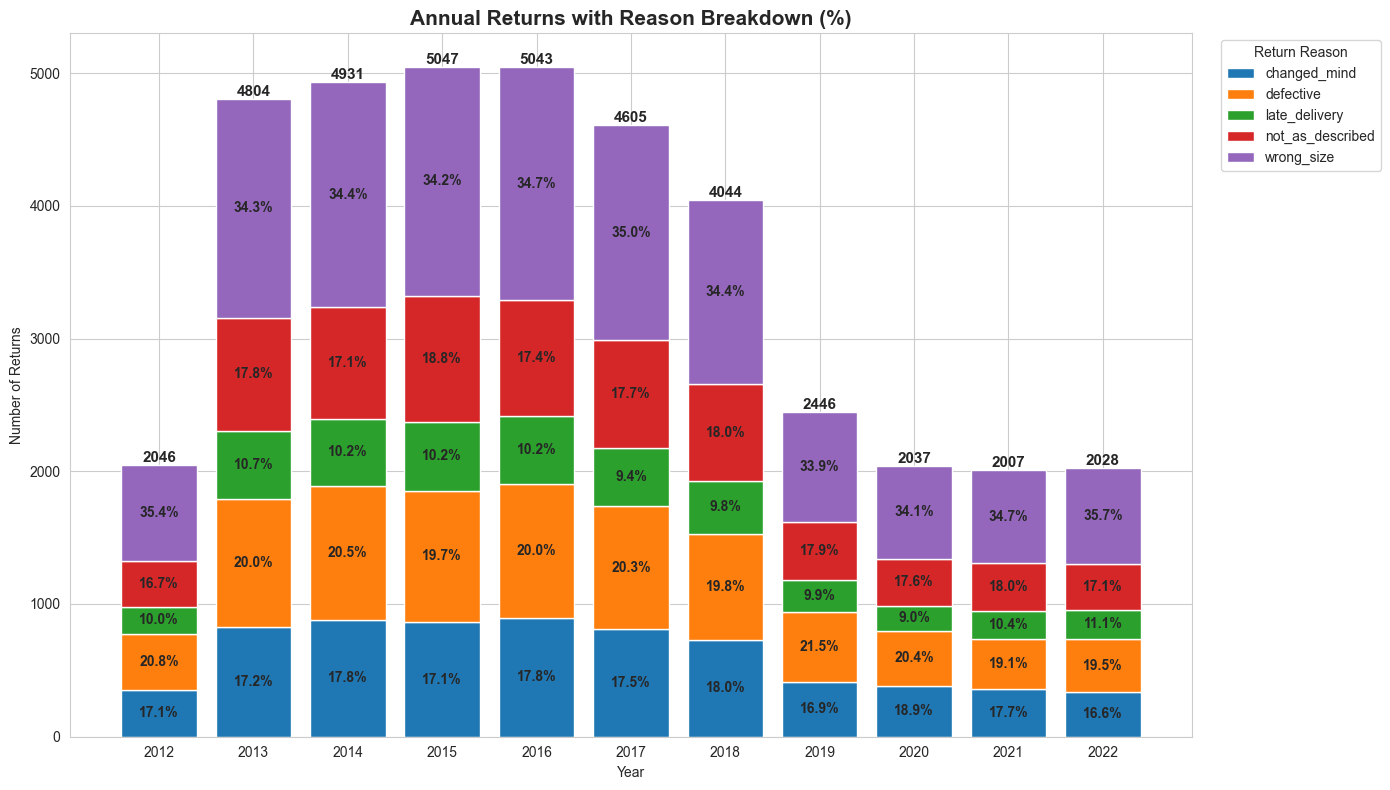

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
orders = pd.read_csv('../data/orders.csv')
returns = pd.read_csv('../data/returns.csv')

# Parse date
orders['order_date'] = pd.to_datetime(orders['order_date'])

df = returns.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

df['year'] = df['order_date'].dt.year

df_unique = df[['order_id', 'year', 'return_reason']].drop_duplicates()


agg = df_unique.groupby(['year', 'return_reason']).size().reset_index(name='count')

pivot = agg.pivot(index='year', columns='return_reason', values='count').fillna(0)

total_returns = pivot.sum(axis=1)
pivot_pct = pivot.div(total_returns, axis=0) * 100

reasons = pivot.columns.tolist()

palette = sns.color_palette("tab10", len(reasons))
color_map = dict(zip(reasons, palette))

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(pivot.index))
bottom = np.zeros(len(pivot))

for col in pivot.columns:
    values = pivot[col].values
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=color_map[col], 
        label=col,
        edgecolor='white'
    )

    pct_vals = pivot_pct[col].values
    for j, (bar, pct) in enumerate(zip(bars, pct_vals)):
        if pct > 3:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom[j] + values[j]/2,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )

    bottom += values

for i, total in enumerate(total_returns):
    ax.text(i, total, f"{int(total)}",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index.astype(int))

ax.set_xlabel("Year")
ax.set_ylabel("Number of Returns")
ax.set_title("Annual Returns with Reason Breakdown (%)", fontsize=15, fontweight='bold')

ax.legend(title="Return Reason", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Prescriptive
Cải thiện sản phẩm

,return_waiting_days,total_returns,churn_count,churn_rate_on_return_waiting_days
0,3,2041,316,0.154826
1,4,2141,350,0.163475
2,5,2159,322,0.149143
3,6,2040,292,0.143137
4,7,2150,320,0.148837
5,8,2108,347,0.164611
6,9,2115,339,0.160284
7,10,2113,342,0.161855
8,11,2100,354,0.168571
9,12,2112,317,0.150095


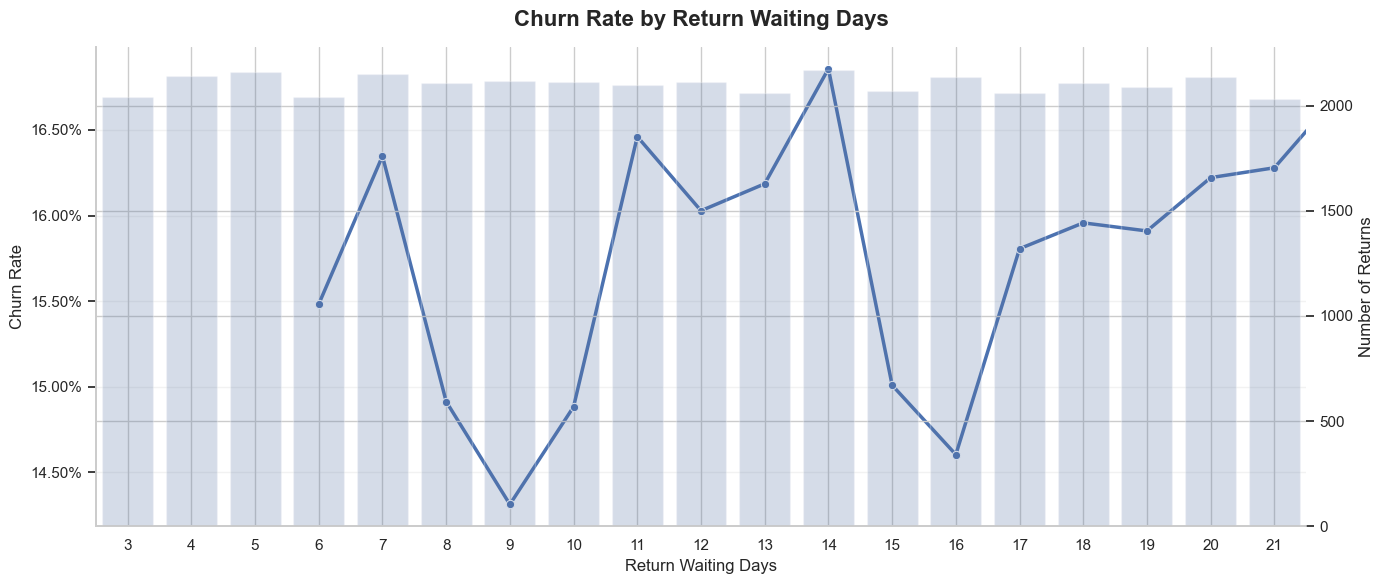

In [12]:
# ===== OPTIMIZED: Return Waiting Days vs Churn =====

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])
returns = pd.read_csv("../data/returns.csv", parse_dates=["return_date"])
shipments = pd.read_csv("../data/shipments.csv", parse_dates=["delivery_date"])

# --------------------------------------------------
# 1. Lấy các đơn hàng bị return
# --------------------------------------------------
returned_orders = (
    orders[orders["order_status"] == "returned"]
    .merge(returns, on="order_id", how="inner")
    .merge(shipments[["order_id", "delivery_date"]], on="order_id", how="inner")
)

returned_orders["return_waiting_days"] = (
    returned_orders["return_date"] - returned_orders["delivery_date"]
).dt.days

returned_orders = returned_orders[
    returned_orders["return_waiting_days"].notna()
    & (returned_orders["return_waiting_days"] >= 0)
].copy()

# --------------------------------------------------
# 2. Tạo bảng tất cả các lần giao hàng
# --------------------------------------------------
all_deliveries = (
    orders
    .merge(shipments[["order_id", "delivery_date"]], on="order_id", how="inner")
    [["customer_id", "order_id", "delivery_date"]]
    .dropna(subset=["delivery_date"])
    .rename(columns={
        "order_id": "next_order_id",
        "delivery_date": "next_delivery_date"
    })
)

# --------------------------------------------------
# 3. Sort đúng chuẩn cho merge_asof
# --------------------------------------------------
returned_orders = returned_orders.sort_values(
    ["return_date", "customer_id"]
).reset_index(drop=True)

all_deliveries = all_deliveries.sort_values(
    ["next_delivery_date", "customer_id"]
).reset_index(drop=True)

# --------------------------------------------------
# 4. Tìm lần giao hàng tiếp theo sau return_date
# --------------------------------------------------
result = pd.merge_asof(
    returned_orders,
    all_deliveries,
    left_on="return_date",
    right_on="next_delivery_date",
    by="customer_id",
    direction="forward",
    allow_exact_matches=False
)

# Nếu match nhầm chính order hiện tại thì loại ra
result.loc[
    result["order_id"] == result["next_order_id"],
    ["next_order_id", "next_delivery_date"]
] = pd.NA

result["churn"] = result["next_delivery_date"].isna()

# --------------------------------------------------
# 5. Tính churn rate theo return_waiting_days
# --------------------------------------------------
churn_by_waiting_days = (
    result
    .groupby("return_waiting_days")
    .agg(
        total_returns=("order_id", "count"),
        churn_count=("churn", "sum")
    )
    .reset_index()
)

churn_by_waiting_days["churn_rate_on_return_waiting_days"] = (
    churn_by_waiting_days["churn_count"] / churn_by_waiting_days["total_returns"]
)

display(churn_by_waiting_days)

# --------------------------------------------------
# 6. Visualization
# --------------------------------------------------
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=churn_by_waiting_days,
    x="return_waiting_days",
    y="churn_rate_on_return_waiting_days",
    marker="o",
    linewidth=2.5,
    ax=ax1
)

ax1.set_xlabel("Return Waiting Days")
ax1.set_ylabel("Churn Rate")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax2 = ax1.twinx()

sns.barplot(
    data=churn_by_waiting_days,
    x="return_waiting_days",
    y="total_returns",
    alpha=0.25,
    ax=ax2
)

ax2.set_ylabel("Number of Returns")

plt.title(
    "Churn Rate by Return Waiting Days",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax1.grid(axis="y", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_11432\993597577.py:12: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")
C:\Users\nguye\AppData\Local\Temp\ipykernel_11432\993597577.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


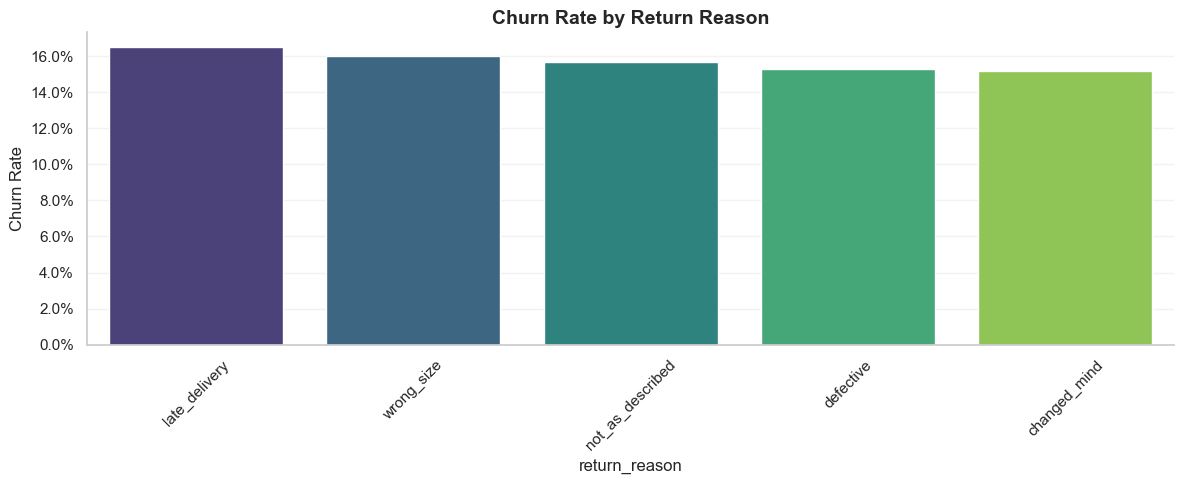

C:\Users\nguye\AppData\Local\Temp\ipykernel_11432\993597577.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


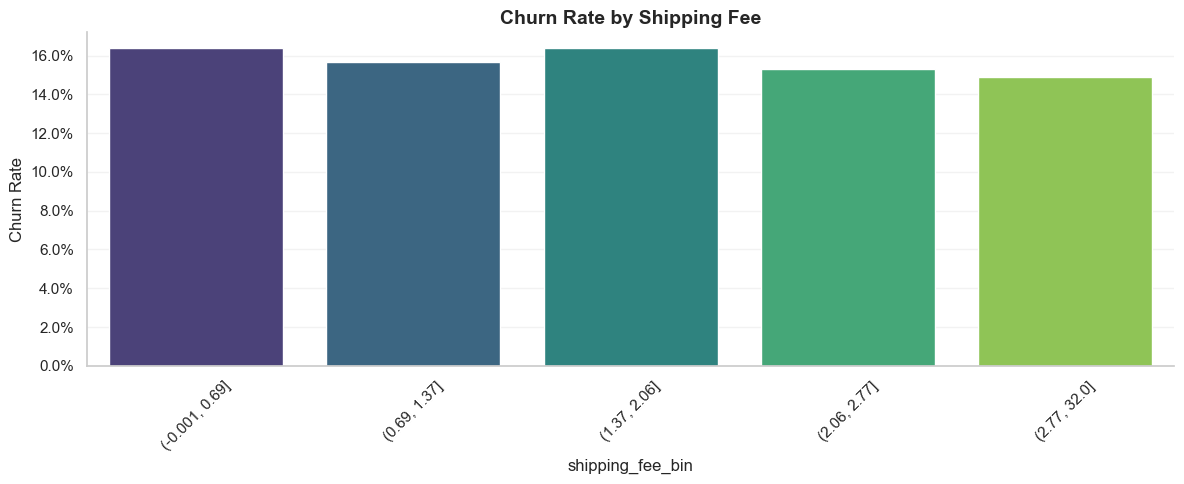

C:\Users\nguye\AppData\Local\Temp\ipykernel_11432\993597577.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


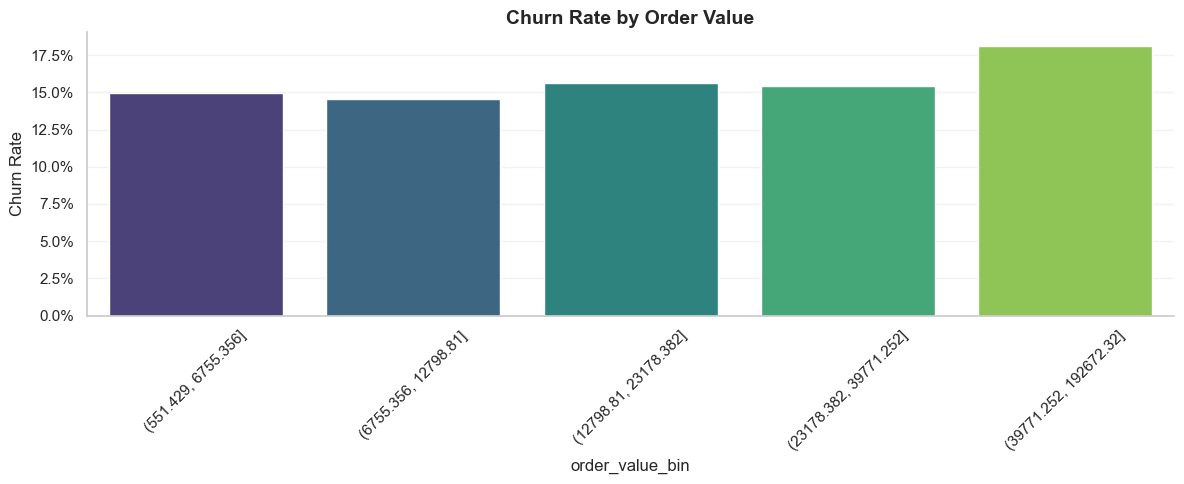

C:\Users\nguye\AppData\Local\Temp\ipykernel_11432\993597577.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


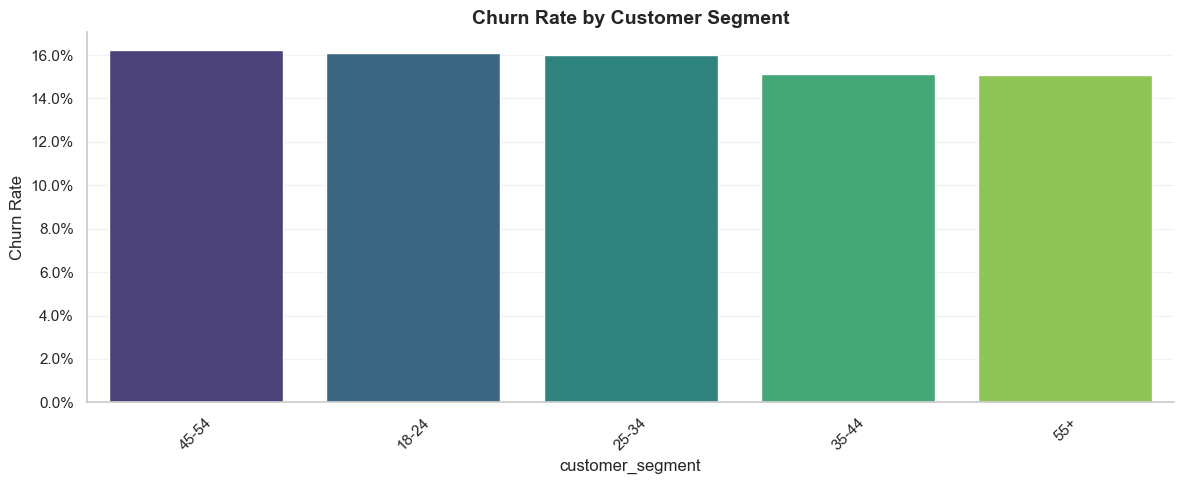

In [13]:
# ===== Churn Drivers Analysis =====

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Load data
orders = pd.read_csv("../data/orders.csv", parse_dates=["order_date"])
returns = pd.read_csv("../data/returns.csv", parse_dates=["return_date"])
shipments = pd.read_csv("../data/shipments.csv", parse_dates=["delivery_date"])
order_items = pd.read_csv("../data/order_items.csv")
customers = pd.read_csv("../data/customers.csv")

# --------------------------------------------------
# 1. Prepare returned_orders
# --------------------------------------------------
returned_orders = (
    orders[orders["order_status"] == "returned"]
    .merge(returns, on="order_id", how="inner")
    .merge(shipments[["order_id", "delivery_date", "shipping_fee"]], on="order_id", how="inner")
)

# --------------------------------------------------
# 2. Compute order_value
# --------------------------------------------------
order_value = (
    order_items
    .assign(revenue=lambda x: x["quantity"] * x["unit_price"])
    .groupby("order_id")["revenue"]
    .sum()
    .reset_index()
)

returned_orders = returned_orders.merge(order_value, on="order_id", how="left")

# --------------------------------------------------
# 3. Add customer info
# --------------------------------------------------
returned_orders = returned_orders.merge(
    customers[["customer_id", "age_group"]],
    on="customer_id",
    how="left"
)

returned_orders = returned_orders.rename(columns={
    "age_group": "customer_segment"
})

# --------------------------------------------------
# 4. Build all deliveries (for churn logic)
# --------------------------------------------------
all_deliveries = (
    orders
    .merge(shipments[["order_id", "delivery_date"]], on="order_id", how="inner")
    [["customer_id", "order_id", "delivery_date"]]
    .rename(columns={
        "order_id": "next_order_id",
        "delivery_date": "next_delivery_date"
    })
    .sort_values(["next_delivery_date", "customer_id"])
)

returned_orders = returned_orders.sort_values(
    ["return_date", "customer_id"]
)

# --------------------------------------------------
# 5. Find next delivery (merge_asof)
# --------------------------------------------------
result = pd.merge_asof(
    returned_orders,
    all_deliveries,
    left_on="return_date",
    right_on="next_delivery_date",
    by="customer_id",
    direction="forward",
    allow_exact_matches=False
)

# remove self-match
result.loc[
    result["order_id"] == result["next_order_id"],
    ["next_order_id", "next_delivery_date"]
] = pd.NA

result["churn"] = result["next_delivery_date"].isna()

# --------------------------------------------------
# 6. Helper function
# --------------------------------------------------
def compute_churn_rate(df, group_col):
    out = (
        df.groupby(group_col)
        .agg(
            total=("order_id", "count"),
            churn_count=("churn", "sum")
        )
        .reset_index()
    )
    out["churn_rate"] = out["churn_count"] / out["total"]
    return out.sort_values("churn_rate", ascending=False)

# --------------------------------------------------
# 7. Plot function
# --------------------------------------------------
def plot_churn(df, x, title):
    plt.figure(figsize=(12, 5))

    sns.barplot(
        data=df,
        x=x,
        y="churn_rate",
        palette="viridis"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.ylabel("Churn Rate")
    plt.xlabel(x)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xticks(rotation=45)

    plt.grid(axis="y", alpha=0.25)
    sns.despine()
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# 8. 1) Churn by return_reason
# --------------------------------------------------
churn_reason = compute_churn_rate(result, "return_reason")
plot_churn(churn_reason, "return_reason", "Churn Rate by Return Reason")

# --------------------------------------------------
# 9. 2) Churn by shipping_fee (binning)
# --------------------------------------------------
result["shipping_fee_bin"] = pd.qcut(result["shipping_fee"], 5, duplicates="drop")

churn_shipping = compute_churn_rate(result, "shipping_fee_bin")
plot_churn(churn_shipping, "shipping_fee_bin", "Churn Rate by Shipping Fee")

# --------------------------------------------------
# 10. 3) Churn by order_value (binning)
# --------------------------------------------------
result["order_value_bin"] = pd.qcut(result["revenue"], 5, duplicates="drop")

churn_value = compute_churn_rate(result, "order_value_bin")
plot_churn(churn_value, "order_value_bin", "Churn Rate by Order Value")

# --------------------------------------------------
# 11. 4) Churn by customer_segment
# --------------------------------------------------
churn_segment = compute_churn_rate(result, "customer_segment")
plot_churn(churn_segment, "customer_segment", "Churn Rate by Customer Segment")

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\nguye\AppData\Local\Temp\ipykernel_16280\2429456325.py:12: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


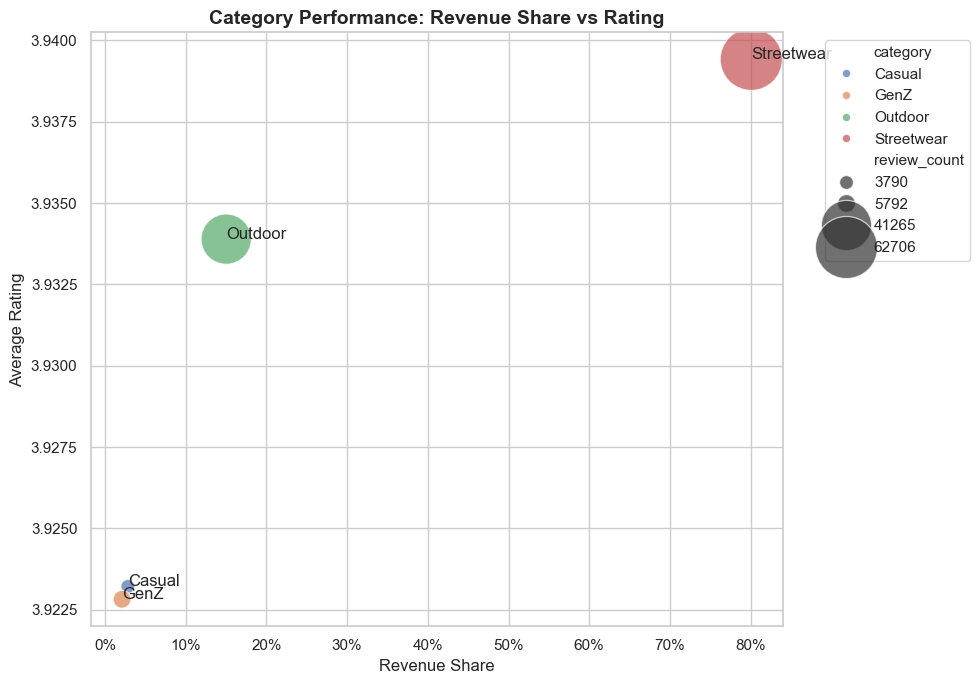

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# Load data
# =========================
products = pd.read_csv("../data/products.csv")
orders = pd.read_csv("../data/orders.csv")
order_items = pd.read_csv("../data/order_items.csv")
reviews = pd.read_csv("../data/reviews.csv")

# =========================
# Compute revenue
# =========================
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"]
    - order_items["discount_amount"]
)

# =========================
# Merge data
# =========================
df = order_items.merge(products[["product_id", "category"]], on="product_id")
df = df.merge(reviews[["order_id", "product_id", "rating"]], 
              on=["order_id", "product_id"], how="left")

# =========================
# Aggregate
# =========================
agg = df.groupby("category").agg(
    revenue=("revenue", "sum"),
    avg_rating=("rating", "mean"),
    review_count=("rating", "count")
).reset_index()

# Revenue share
agg["revenue_share"] = agg["revenue"] / agg["revenue"].sum()

# =========================
# Plot bubble chart
# =========================
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=agg,
    x="revenue_share",
    y="avg_rating",
    size="review_count",
    sizes=(100, 2000),
    hue="category",
    alpha=0.7
)

for i, row in agg.iterrows():
    plt.text(row["revenue_share"], row["avg_rating"], row["category"])

plt.title("Category Performance: Revenue Share vs Rating", fontsize=14, fontweight="bold")
plt.xlabel("Revenue Share")
plt.ylabel("Average Rating")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()